# Loan Approval Analysis and Prediction

## Data Analytics Main Project

### Submitted By: Linto Christy Manoj

## 1. Introduction

Loan approval is an important process in the banking sector that depends on factors such as income, credit history, education, employment status, and loan amount. This project uses a loan applicant dataset to analyze the relationship between applicant details and loan approval status.

The project includes data preprocessing, exploratory data analysis (EDA), and visualization to understand the key factors influencing loan approval. Python libraries such as **Pandas** and **NumPy** are used for data preprocessing and analysis, while **Matplotlib** and **Seaborn** are used for data visualization and identifying patterns in the dataset.

## 2. Problem Statement

Loan approval depends on multiple applicant-related factors, making eligibility decisions complex. This project aims to analyze the loan applicant dataset to identify the factors influencing loan approval and understand patterns related to applicant characteristics.


## 3. Objectives of the Project

The objectives of this project are:

- To understand the structure of the loan dataset.
- To preprocess and clean the data.
- To perform exploratory data analysis (EDA).
- To visualize important patterns in the dataset.
- To identify factors influencing loan approval.


### Dataset Overview

The dataset contains loan applicant information, including demographic details, financial information, credit history, loan amount, and loan approval status. Data preprocessing is performed to improve data quality and ensure consistency.

Dataset Size
Rows: 614
Columns: 13

### Tools and Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook



## 4. Data Loading and Overview

In this step, the loan applicant dataset is loaded and examined to understand its structure and contents. An initial overview of the dataset helps in identifying available features, data organization, and preparing the data for preprocessing and analysis.

### importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Dataset

In [2]:
df = pd.read_csv("Loan_dataset-2024.csv")

### View First 5 Rows

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,?,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,'Not Graduate',No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Dataset Shape

In [4]:
df.shape

(614, 13)

#### The Dataset Contains-
- 614 Rows
- 13 Columns

### Column Names

In [5]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

### Dataset Info

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    str    
 9   Loan_Amount_Term   614 non-null    str    
 10  Credit_History     614 non-null    str    
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(1), int64(1), str(11)
memory usage: 62.5 KB


#### Observations

- The dataset contains **614 records** and **13 columns**.
- No missing values are observed, as all columns contain **614 non-null entries**.
- Most features are stored as **string (`str`) datatype**.
- `ApplicantIncome` and `CoapplicantIncome` are stored as numerical datatypes (`int64` and `float64`).
- Columns such as `LoanAmount`, `Loan_Amount_Term`, and `Credit_History` are stored as strings, although they may contain numerical values and may require datatype conversion during preprocessing.

### Statistical Summary

In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome
count,614.000000,614.000000
mean,5403.459283,1621.245798
std,6109.041673,2926.248369
min,150.000000,0.000000
25%,2877.500000,0.000000
50%,3812.500000,1188.500000
75%,5795.000000,2297.250000
max,81000.000000,41667.000000


#### Observations
In this dataset, 
- Only `ApplicantIncome` and `CoapplicantIncome` are recognized as numerical datatypes, so descriptive statistics are shown only for these two features.
- Columns such as `LoanAmount`, `Loan_Amount_Term`, and `Credit_History` are not included because they are currently stored as string (`str`) datatype.
- These columns may contain numerical information and will be converted to appropriate numerical datatypes during preprocessing to enable proper statistical analysis.

# 4. Data Pre-processing

### 4.1. Renaming Column Names

In this step, selected column names are renamed to improve readability and maintain a consistent naming format. Underscores (`_`) are added between words to make column names easier to understand and work with during further analysis and preprocessing.

In [8]:
df.rename(columns={"ApplicantIncome":"Applicant_Income","CoapplicantIncome":"Coapplicant_Income","LoanAmount":"Loan_Amount"},inplace=True)

### 4.2. Removing Extra Spaces from Column Names

In [9]:
df.columns = df.columns.str.strip()

### 4.3. Checking for Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

It seems there is no Duplicate rows in the dataset since the ouput is "0"

### 4.5. Checking for Null Values

In [11]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64


Although the dataset does not contain null values, categorical columns may still contain inconsistent or invalid entries. Therefore, unique values are examined to identify possible inconsistencies, unusual categories, or formatting issues that may require preprocessing.

###  4.6. Checking Unique Values for Inconsistencies


In [12]:
df.nunique() #number of unique values 

Loan_ID               614
Gender                  3
Married                 3
Dependents              5
Education               2
Self_Employed           3
Applicant_Income      505
Coapplicant_Income    287
Loan_Amount           204
Loan_Amount_Term       11
Credit_History          3
Property_Area           3
Loan_Status             2
dtype: int64

### 4.7. Identifying Unique values from Each columns using "for" loop 

In [13]:

for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique())


Loan_ID
<StringArray>
['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011',
 'LP001013', 'LP001014', 'LP001018', 'LP001020',
 ...
 'LP002959', 'LP002960', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 614, dtype: str

Gender
<StringArray>
['Male', 'Female', '?']
Length: 3, dtype: str

Married
<StringArray>
['No', 'Yes', '?']
Length: 3, dtype: str

Dependents
<StringArray>
['0', '1', '2', '3+', '?']
Length: 5, dtype: str

Education
<StringArray>
['Graduate', ''Not Graduate'']
Length: 2, dtype: str

Self_Employed
<StringArray>
['No', 'Yes', '?']
Length: 3, dtype: str

Applicant_Income
[ 5849  4583  3000  2583  6000  5417  2333  3036  4006 12841  3200  2500
  3073  1853  1299  4950  3596  3510  4887  2600  7660  5955  3365  3717
  9560  2799  4226  1442  3750  4166  3167  4692  3500 12500  2275  1828
  3667  3748  3600  1800  2400  3941  4695  3410  5649  5821  2645  4000
  1928  3086  4230  4616 11500  2708  2

Observation:

Although no null values were detected initially, examining the unique values revealed that missing entries are stored as `"?"` in some columns. Since `"?"` is treated as a normal string value rather than a null value (`NaN`), it was not identified during the missing value check.

It was also observed that the `Education` column contains inconsistent formatting, where values such as `'Not Graduate'` may require standardization for consistency during preprocessing.

Therefore, hidden missing values and inconsistent categorical entries need to be handled to improve data quality and ensure accurate analysis.

### 4.8. Handling missing values and Inconsistant entries

#### Identifying the number of "?" missing values in each columns

In [14]:
(df == "?").sum()

Loan_ID                0
Gender                13
Married                3
Dependents            15
Education              0
Self_Employed         32
Applicant_Income       0
Coapplicant_Income     0
Loan_Amount           22
Loan_Amount_Term      14
Credit_History        50
Property_Area          0
Loan_Status            0
dtype: int64

Observation: 
   Most of the coulmns have "?" entries, meaning it should be replaced or handled.

### 4.9. Handling missing values (column wise)

Replacing missing values (`"?"`) in the `Gender', 'Married','Dependents`,`Self_Employed`,'Credit_History','Loan_Amount_Term' columns with the most frequently occurring value (mode) to maintain consistency in the dataset.

In [15]:
df["Gender"] = df["Gender"].replace("?", df["Gender"].mode()[0])

In [16]:
df["Married"] = df["Married"].replace("?", df["Married"].mode()[0])

In [17]:
df["Dependents"] = df["Dependents"].replace("?", df["Dependents"].mode()[0])
df["Dependents"] = df["Dependents"].replace("3+",3)  
#converting `"3+"` to `3` to standardize the data and enable later conversion to numerical datatype.

In [18]:
df["Self_Employed"] = df["Self_Employed"].replace("?", df["Self_Employed"].mode()[0])

In [19]:
df["Credit_History"] = df["Credit_History"].replace("?", df["Credit_History"].mode()[0])

In [20]:
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].replace("?", df["Loan_Amount_Term"].mode()[0])

Replacing missing values (`"?"`) in the Loan_Amount with median to maintain consistency in the dataset.

In [21]:
df["Loan_Amount"] = df["Loan_Amount"].replace("?", np.nan).astype(float)
df["Loan_Amount"] = df["Loan_Amount"].fillna(df["Loan_Amount"].median()).round(2)

Replacing `"?"` values in the `Loan_Amount` column with `NaN`, converting the column to numerical datatype, 
and filling missing values using the median since it is more suitable for numerical data like "Loan Amount" and less affected by extreme values.

### 4.10. Handling Data Inconsistencies

Replacing abbreviated values in the `Loan_Status` column with meaningful labels and correcting formatting inconsistencies in the `Education` column to improve readability and maintain data consistency.

In [22]:
df["Loan_Status"] = df["Loan_Status"].replace({"Y":"Approved", "N":"Rejected"})

df["Education"] = df["Education"].replace("'Not Graduate'", "Not Graduate")

In [23]:
(df == "?").sum() #RECHECKING 

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

### 4.11. Changing data type

Converting selected columns from string datatype to numerical format to enable accurate statistical analysis, calculations, and visualization during later stages of the project.

In [24]:
df["Dependents"] = pd.to_numeric(df["Dependents"])
df["Loan_Amount"] = pd.to_numeric(df["Loan_Amount"])
df["Loan_Amount_Term"] = pd.to_numeric(df["Loan_Amount_Term"])
df["Credit_History"] = pd.to_numeric(df["Credit_History"])

Removing leading and trailing spaces from string columns to ensure consistent formatting and prevent duplicate categories caused by unwanted whitespace.

In [25]:
df["Gender"] = df["Gender"].str.strip()
df["Married"] = df["Married"].str.strip()
df["Education"] = df["Education"].str.strip()
df["Self_Employed"] = df["Self_Employed"].str.strip()
df["Property_Area"] = df["Property_Area"].str.strip()
df["Loan_Status"] = df["Loan_Status"].str.strip()

### 4.12. Derived Columns

Creating a new column `Total_Income` by combining applicant and co-applicant income to represent the total household income of the applicant.

In [26]:
df["Total_Income"] = df["Applicant_Income"] + df["Coapplicant_Income"]

Creating an `Income_Category` column by grouping applicant income into low, average, and high-income categories to simplify income-based analysis.

In [27]:
def income_category(income):
    if income < 4000:
        return "Low Income"
    elif income < 10000:
        return "Average Income"
    else:
        return "High Income"

df["Income_Category"] = df["Applicant_Income"].apply(income_category)



Creating new derived column called `Actual_Loan_Amount` by multiplying the existing `Loan_Amount` values by 1000.
Because, the original `Loan_Amount` values in the dataset appear to be stored in thousands for compact representation. Creating a derived column helps represent the actual loan value more clearly while preserving the original dataset values.

In [28]:
df["Actual_Loan_Amount"] = df["Loan_Amount"] * 1000

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             614 non-null    str    
 1   Gender              614 non-null    str    
 2   Married             614 non-null    str    
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    str    
 5   Self_Employed       614 non-null    str    
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    float64
 9   Loan_Amount_Term    614 non-null    float64
 10  Credit_History      614 non-null    float64
 11  Property_Area       614 non-null    str    
 12  Loan_Status         614 non-null    str    
 13  Total_Income        614 non-null    float64
 14  Income_Category     614 non-null    str    
 15  Actual_Loan_Amount  614 non-null    float64
dtypes: float64(6), int6

In [30]:
df.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Total_Income,Actual_Loan_Amount
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,5403.459283,1621.245798,145.752443,342.410423,0.855049,7024.705081,145752.442997
std,1.009623,6109.041673,2926.248369,84.107233,64.428629,0.352339,6458.663872,84107.233380
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,1442.000000,9000.000000
25%,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,4166.000000,100250.000000
50%,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,5416.500000,128000.000000
75%,1.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,7521.750000,164750.000000
max,3.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,81000.000000,700000.000000


## 5. Exploratory Data Analysis

##### 5.1. Loan Approval Status Summary


In [31]:
Approval_Status = pd.pivot_table(
    df, index="Loan_Status",
    values="Loan_ID",
    aggfunc="count")

Approval_Status["Percentage"] = ((Approval_Status["Loan_ID"] / Approval_Status["Loan_ID"].sum()) * 100).round(1)

In [32]:
Approval_Status

,Loan_ID,Percentage
Loan_Status,,
Approved,422,68.7
Rejected,192,31.3


#### Insight

Most loan applications were approved, with 68.7% approved and 31.3% rejected.

####  5.2. Credit History and Loan Approval Analysis

In [33]:
Credit_History_Analysis = pd.pivot_table(
    df, index="Credit_History",
    columns="Loan_Status",
    values="Loan_ID",
    aggfunc="count",
    fill_value=0)

Credit_History_Analysis

Loan_Status,Approved,Rejected
Credit_History,,
0.0,7,82
1.0,415,110


#### Insight

Applicants with a credit history were more likely to have their loans approved compared to those without a credit history.

#### 5.3. Income Category and Loan Approval

In [34]:
Income_Category_Distribution = pd.pivot_table(
df, index="Income_Category",
columns="Loan_Status",
values="Loan_ID",
aggfunc="count")

Income_Category_Distribution["Total"] = (Income_Category_Distribution["Approved"] + Income_Category_Distribution["Rejected"])

Income_Category_Distribution["Approval_Percentage"] = (Income_Category_Distribution["Approved"] / Income_Category_Distribution["Total"] * 100).round(2)

Income_Category_Distribution["Rejection_Percentage"] = (Income_Category_Distribution["Rejected"] /Income_Category_Distribution["Total"] * 100).round(2)

Income_Category_Distribution

Loan_Status,Approved,Rejected,Total,Approval_Percentage,Rejection_Percentage
Income_Category,,,,,
Average Income,156,72,228,68.42,31.58
High Income,35,20,55,63.64,36.36
Low Income,231,100,331,69.79,30.21


**Insight:** Approval rates remain fairly consistent across all income categories. Low-income applicants have the highest approval rate (69.8%), while high-income applicants have the lowest (63.6%). This suggests that income category by itself does not strongly influence loan approval outcomes.

#### 5.4. Loan Amount Summary Statistics

In [35]:
df["Actual_Loan_Amount"].agg(["count", "mean", "median", "min", "max"])

count        614.000000
mean      145752.442997
median    128000.000000
min         9000.000000
max       700000.000000
Name: Actual_Loan_Amount, dtype: float64

#### 5.5. Property Area and Loan Amount Analysis

In [36]:
Property_Area_vs_Loan_Amount = pd.pivot_table(df,
index="Property_Area",
values="Actual_Loan_Amount",
aggfunc=["mean","median","min","max"]).round(1)

Property_Area_vs_Loan_Amount.columns = ["Mean","Median","Min","Max"]

Property_Area_vs_Loan_Amount

,Mean,Median,Min,Max
Property_Area,,,,
Rural,151446.9,132000.0,40000.0,570000.0
Semiurban,145128.8,128000.0,25000.0,600000.0
Urban,141425.7,121000.0,9000.0,700000.0


**Insight:** Rural areas have the highest average and median loan amounts, while urban areas have the lowest average loan amount. However, urban applicants received the highest maximum loan amount among all property areas.


#### 5.6. Education, Income and Loan Approval Analysis

In [37]:
Education_vs_Income = pd.pivot_table(df,
index="Education",
values="Applicant_Income",
aggfunc=["count","mean","median","min","max"]).round(1)

Education_vs_Income.columns = ["Count","Mean","Median","Min","Max"]

Approval_Percentage = pd.pivot_table(df,
index="Education",
values="Loan_ID",
columns="Loan_Status",
aggfunc="count")

Approval_Percentage["Approval_Percentage"] = (Approval_Percentage["Approved"] /(Approval_Percentage["Approved"] + Approval_Percentage["Rejected"])* 100).round(2)

Education_vs_Income["Approval_Percentage"] = Approval_Percentage["Approval_Percentage"]

Education_vs_Income

,Count,Mean,Median,Min,Max,Approval_Percentage
Education,,,,,,
Graduate,480,5857.4,4000.0,150,81000,70.83
Not Graduate,134,3777.3,3357.5,210,18165,61.19


**Insight:** Graduates have a higher average income and a higher loan approval rate (70.83%) compared to non-graduates (61.19%), suggesting that education may positively influence loan approval outcomes.


#### 5.7. Income Category, Dependents and Loan Status Analysis

In [38]:
multivariate_analysis = pd.crosstab(
[df["Income_Category"], df["Dependents"]],
df["Loan_Status"],
margins=True)

multivariate_analysis

Loan_Status                 Approved  Rejected  All
Income_Category Dependents                         
Average Income  0                 78        42  120
                1                 25        13   38
                2                 34        11   45
                3                 19         6   25
High Income     0                 17        11   28
                1                  7         7   14
                2                  6         0    6
                3                  5         2    7
Low Income      0                152        60  212
                1                 34        16   50
                2                 36        14   50
                3                  9        10   19
All                              422       192  614

**Insight:** Applicants across most income categories and dependent groups have more loan approvals than rejections. The highest number of approvals is observed among low-income applicants with no dependents, while applicants with three dependents generally show lower approval counts compared to other groups.

#### 5.8. Gender, Education and Loan Approval Analysis

In [39]:
gender_education_approval = (
df.groupby(["Gender","Education","Loan_Status"]).size().unstack(fill_value=0))

gender_education_approval["Approval_%"] = (
gender_education_approval["Approved"]/ (gender_education_approval["Approved"] + gender_education_approval["Rejected"])* 100).round(2)

gender_education_approval

Loan_Status          Approved  Rejected  Approval_%
Gender Education                                   
Female Graduate            61        31       66.30
       Not Graduate        14         6       70.00
Male   Graduate           279       109       71.91
       Not Graduate        68        46       59.65

**Insight:** Male graduates have the highest loan approval rate (71.91%), while male non-graduates have the lowest approval rate (59.65%). Overall, graduates tend to have higher approval rates than non-graduates regardless of gender.


#### 5.9. Income and Loan Amount Correlation Analysis

In [40]:
df[["Total_Income", "Actual_Loan_Amount"]].corr()

,Total_Income,Actual_Loan_Amount
Total_Income,1.000000,0.620316
Actual_Loan_Amount,0.620316,1.000000


**Insight:** There is a moderate positive correlation (**0.62**) between total income and loan amount. This suggests that applicants with higher incomes generally tend to receive larger loan amounts.


## 6. Visualization

#### 6.1. Loan Approval Distribution - Pie Chart 

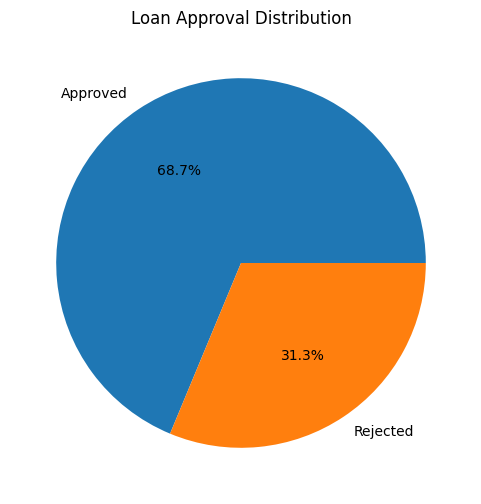

In [41]:
loan_counts = df["Loan_Status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(loan_counts.values,
labels = loan_counts.index,
autopct = "%1.1f%%")

plt.title("Loan Approval Distribution")

plt.show()

**Insight:** The pie chart shows that most loan applications were approved, accounting for about 68.7% of the total applications, while 31.3% were rejected.



#### 6.2. Credit History vs Loan Status (Count Plot)

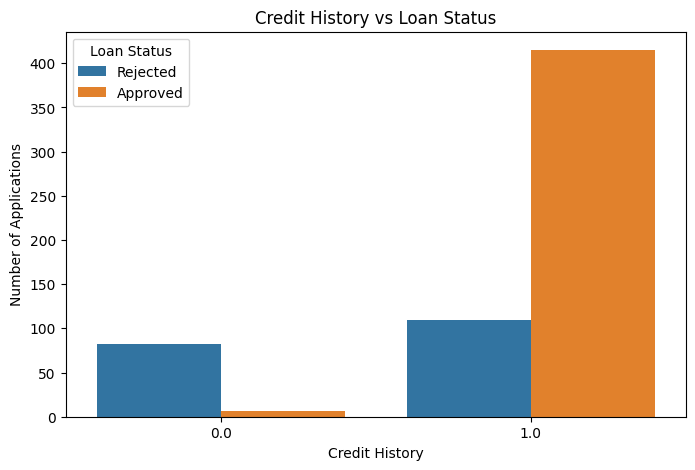

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(data = df,
x = "Credit_History",
hue = "Loan_Status")

plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Number of Applications")
plt.legend(title = "Loan Status")

plt.show()


**Insight:** Applicants with a credit history have a much higher number of loan approvals compared to applicants without a credit history.

#### 6.3. Distribution of Applicant Income

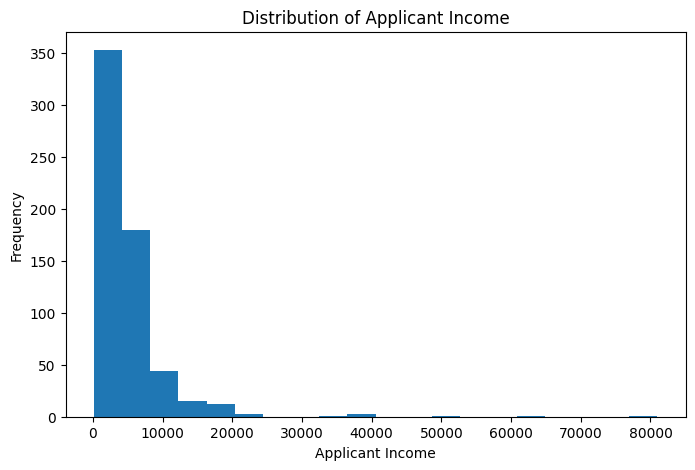

In [43]:
plt.figure(figsize=(8,5))

plt.hist(df["Applicant_Income"], bins = 20)

plt.title("Distribution of Applicant Income")

plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

**Insight:** The applicant income distribution is positively skewed, with most applicants concentrated in lower income ranges and a small number of applicants earning exceptionally high incomes. This indicates that loan applications are primarily submitted by middle- and lower-income individuals.

#### 6.4. Loan Amount Distribution by Gender (Violin Plot)

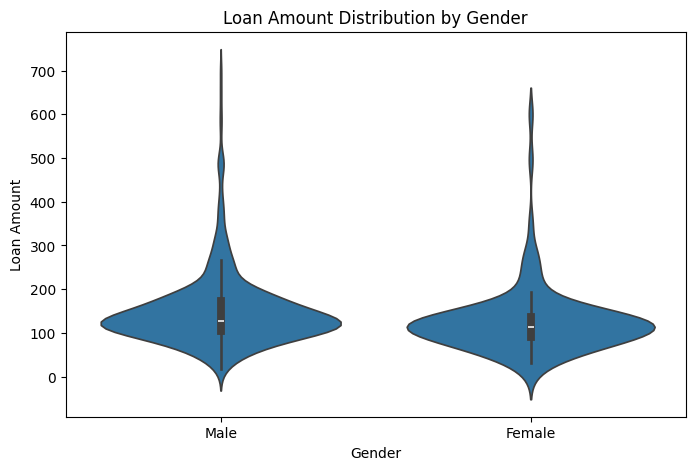

In [44]:
plt.figure(figsize=(8,5))

sns.violinplot(data = df,
x = "Gender",
y = "Loan_Amount")

plt.title("Loan Amount Distribution by Gender")

plt.xlabel("Gender")
plt.ylabel("Loan Amount")

plt.show()

**Insight:** The distribution of loan amounts is similar across genders, although the spread and concentration of loan amounts may vary between male and female applicants.

#### 6.5. Income Category vs Loan Status (Count Plot)

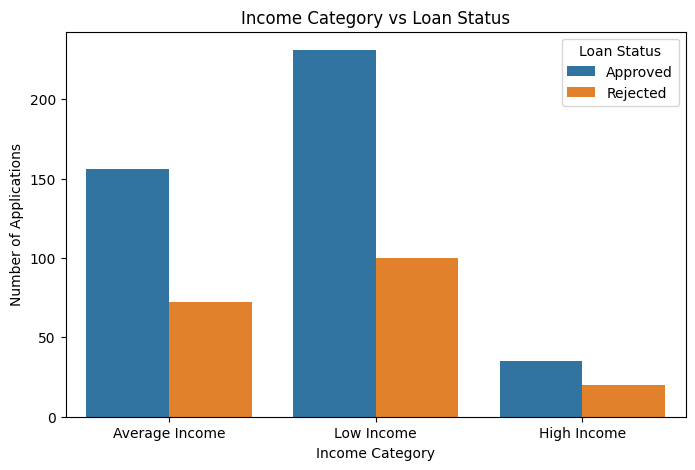

In [45]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df,
    x="Income_Category",
    hue="Loan_Status")

plt.title("Income Category vs Loan Status")
plt.xlabel("Income Category")
plt.ylabel("Number of Applications")
plt.legend(title="Loan Status")

plt.show()

**Insight:** Loan approvals are higher than rejections across all income categories, with the largest number of applications coming from the low-income group

#### 6.6. Property Area vs Loan Status - 100% Stacked Bar Chart

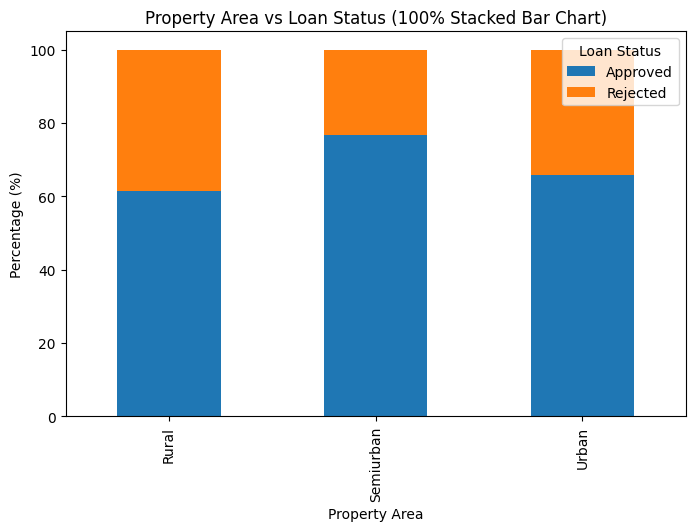

In [46]:
property_area = pd.crosstab(df["Property_Area"],
df["Loan_Status"],
normalize = "index") * 100

property_area.plot(
kind = "bar",
stacked = True,
figsize = (8,5))

plt.title("Property Area vs Loan Status (100% Stacked Bar Chart)")

plt.xlabel("Property Area")
plt.ylabel("Percentage (%)")

plt.legend(title = "Loan Status")

plt.show()



**Insight:** Semiurban applicants have the highest loan approval rate, indicating a greater likelihood of receiving loan approval compared to Rural and Urban applicants. However, the differences between regions remain moderate, suggesting that property area has a secondary influence on approval outcomes.


#### 6.7. Applicant Income vs Loan Amount (Scatter Plot)

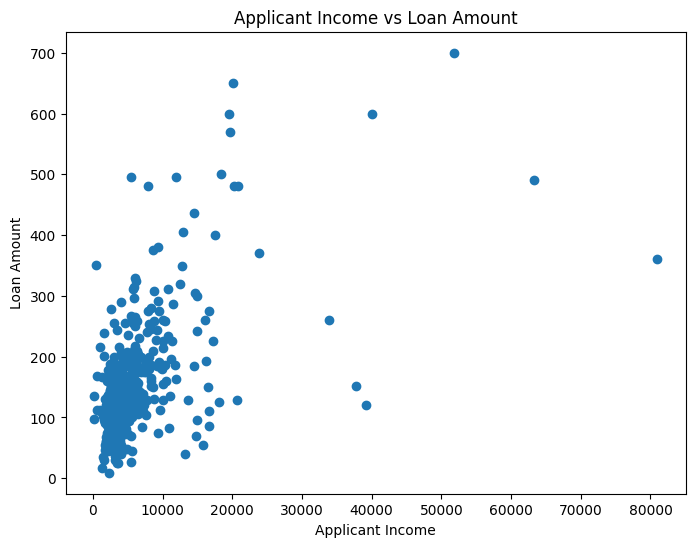

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(df["Applicant_Income"],df["Loan_Amount"])

plt.title("Applicant Income vs Loan Amount")

plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")

plt.show()

**Insight:** The scatter plot indicates a positive relationship between applicant income and loan amount, meaning that applicants with higher incomes generally tend to receive larger loans. However, the points are not tightly clustered around a single trend, suggesting that income is not the only factor influencing loan amounts. There is noticeable variability among applicants with similar income levels, and a few high-income applicants receive exceptionally large loans, creating potential outliers. Overall, the chart suggests a moderate positive association between income and loan amount, which is consistent with the correlation coefficient of **0.62** observed earlier.


#### 6.8. Applicant Income vs Total Income

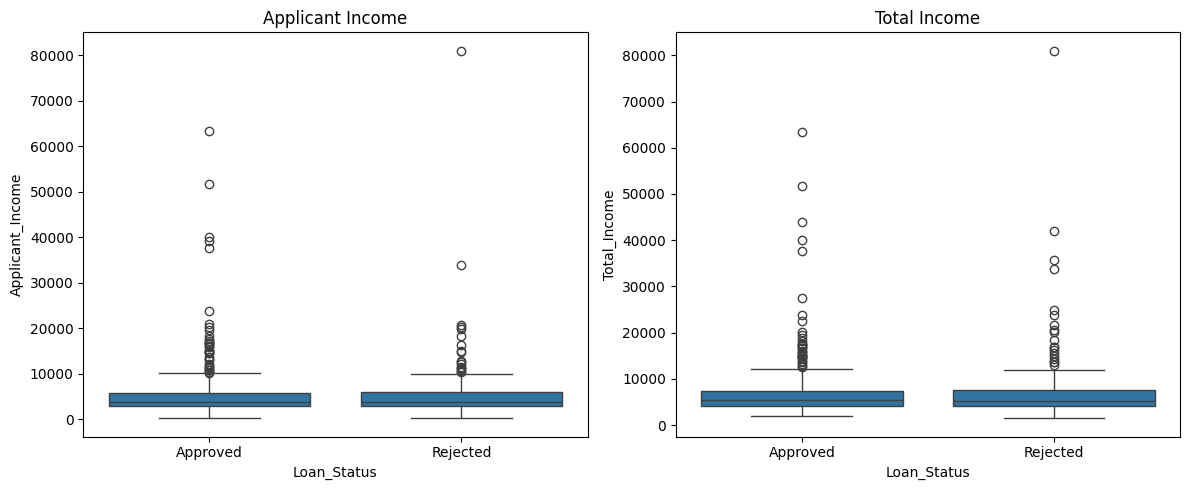

In [48]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(data = df,
x = "Loan_Status",
y = "Applicant_Income",
ax = axes[0])

axes[0].set_title("Applicant Income")

sns.boxplot(data = df,
x = "Loan_Status",
y = "Total_Income",
ax = axes[1])

axes[1].set_title("Total Income")

plt.tight_layout()

plt.show()

**Insight:** Both applicant income and total income display very similar distributions across approved and rejected applicants. Since neither variable shows a clear distinction between the two groups, the visual evidence suggests that neither income measure is a strong determining factor in loan approval. Therefore, the box plots do not indicate that total income is more important than applicant income, or vice versa.

#### 6.9. Approval rate based on Number of Dependents - Lollipop Chart

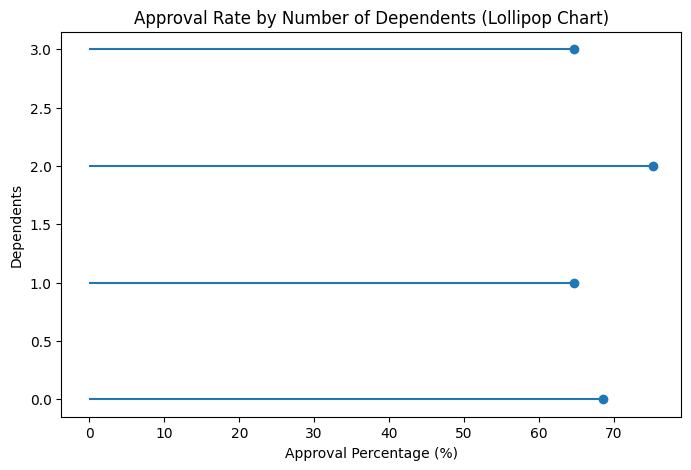

In [49]:
dependents = pd.crosstab(df["Dependents"],df["Loan_Status"])

dependents["Approval_Percentage"] = (dependents["Approved"] / (dependents["Approved"] + dependents["Rejected"])* 100).round(2)

plt.figure(figsize=(8,5))

plt.hlines(
y = dependents.index,
xmin = 0,
xmax = dependents["Approval_Percentage"])

plt.scatter( dependents["Approval_Percentage"], dependents.index)

plt.title("Approval Rate by Number of Dependents (Lollipop Chart)")

plt.xlabel("Approval Percentage (%)")
plt.ylabel("Dependents")

plt.show()

**Insight:** Loan approval rates are fairly similar across all dependent groups. Although applicants with 2 dependents have a slightly higher approval rate and those with 3 dependents have a lower rate, the overall pattern indicates that the number of dependents is not a major factor in loan approval decisions.

#### 6.10. Approval Rate by Loan Term (Line Chart)

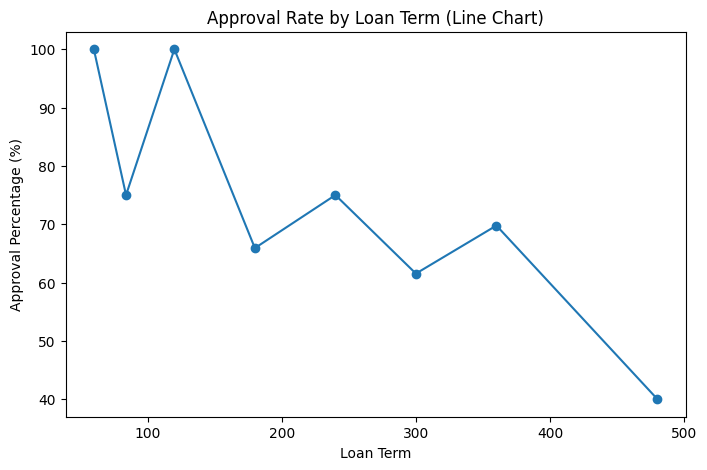

In [50]:
loan_term = pd.crosstab(df["Loan_Amount_Term"],
df["Loan_Status"])

loan_term = loan_term[loan_term.index >= 60]

loan_term["Approval_Percentage"] = ( loan_term["Approved"] / (loan_term["Approved"] + loan_term["Rejected"])* 100)

plt.figure(figsize=(8,5))

plt.plot(loan_term.index, loan_term["Approval_Percentage"], marker = "o")

plt.title("Approval Rate by Loan Term (Line Chart)")

plt.xlabel("Loan Term")
plt.ylabel("Approval Percentage (%)")

plt.show()

**Insight:** Approval rates remain fairly consistent for most loan terms, with the majority ranging between 60% and 75%. While some shorter loan terms have higher approval rates, there is no strong trend indicating that longer or shorter loan terms significantly affect loan approval decisions. This suggests that loan term is not a primary factor in the approval process.

#### 6.11. Approval Rate by Marital Status and Education (Heatmap)

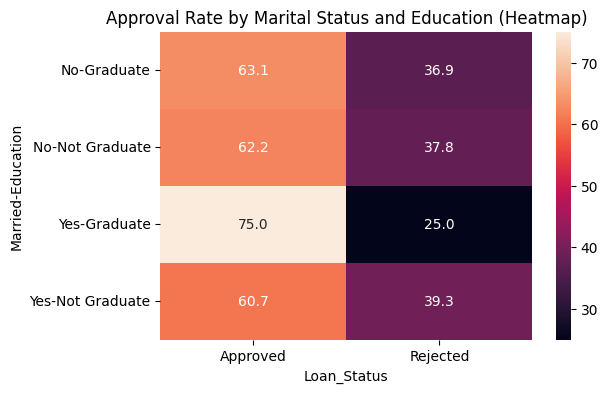

In [53]:
married_education = pd.crosstab([df["Married"], df["Education"]],df["Loan_Status"], normalize = "index") * 100

plt.figure(figsize=(6,4))

sns.heatmap(married_education,
annot = True,
fmt = ".1f")

plt.title("Approval Rate by Marital Status and Education (Heatmap)")

plt.show()


**Insight:** Married graduates show the highest approval rate (75%), while married non-graduates have the lowest (60.7%). Approval rates among unmarried applicants are fairly similar regardless of education level, indicating that the combination of marital status and education may influence loan approval outcomes more than either factor individually.


## Insights and Report
### 1. Summary of Key Insights

The analysis explored various applicant, financial, and demographic factors influencing loan approval decisions. Data cleaning and feature engineering were performed to handle missing values and create meaningful variables such as Total Income and Income Categories. Exploratory Data Analysis revealed that loan approval decisions are primarily driven by an applicant's financial reliability rather than demographic characteristics.

#### Key findings:

- The overall loan approval rate is approximately 68.7%.
  
- Credit History is the strongest factor influencing loan approval.
  
- Education and Property Area show moderate influence on approval outcomes.
  
- Income, Dependents, Gender, and Loan Term have relatively low influence on approval decisions.
  
- Higher incomes are associated with larger loan amounts, but not necessarily higher approval rates.


### 2. Patterns, Correlations, and Anomalies
#### Patterns
- Applicants with a positive Credit History have substantially higher approval rates.

- Graduates generally perform better than non-graduates in loan approvals.

- Applicants from Semiurban areas show better approval performance compared to Urban and Rural applicants.

- Married graduates exhibit the strongest approval outcomes among combined demographic groups.

#### Correlations

- A positive relationship exists between Total Income and Loan Amount, indicating that applicants with higher incomes tend to apply for or receive 
larger loans.

- Co-applicant income contributes to overall borrowing capacity and loan size.

#### Anomalies
- Income and Loan Amount variables contained several extreme but realistic high-value observations. These reflect genuine variation in applicants'   financial profiles rather than data quality issues and contribute to the right-skewed nature of the distributions.

- Some low-income applicants received approvals due to strong credit profiles.

- A few high-income applicants were rejected, indicating that income alone is not sufficient for loan approval.

- Although Income showed a relatively low influence on approval rates, it remains an important financial factor. The positive correlation between Income and Loan Amount suggests that higher-income applicants tend to request larger loans. This may explain why the effect of income is not strongly reflected in approval rates alone.




### 3. Influence of Factors on Loan Approval
| Influence Level          | Factors                                                   |
| ------------------------ | --------------------------------------------------------- |
| **High Influence**       | Credit History                                            |
| **Moderate Influence**   | Education, Property Area, Marital Status, Self-Employment |
| **Low Influence**        | Income, Gender, Dependents, Loan Term            |
| **Related to Loan Size** | Applicant Income, Co-applicant Income, Total Income       |





### 4. Conclusion 

The analysis shows that **Credit History is the most important factor influencing loan approval**, highlighting the importance of financial reliability. **Education, Property Area, Marital Status, and Self-Employment** have a moderate impact, while **Dependents, Gender, and Loan Term** show relatively low influence. Although **Income** does not strongly affect approval rates, its positive correlation with **Loan Amount** suggests it plays an indirect role in lending decisions. Overall, loan approvals appear to depend more on **creditworthiness and financial stability** than on demographic characteristics alone.


